# Notebook 1 — Linear & Ridge Regression Forecasting

**MediShift · Forecasting Engine, Model 1 of 3**

This notebook reproduces, from first principles, the first of the three fitted
forecasting models described in **Chapter 2 ("Machine Learning and Predictions")**
of the MediShift project report: a recency-weighted **Ridge Regression** model that
predicts patient inflow for a single hospital shift.

Everything here is built the same way the report derives it — the ordinary
least-squares normal equations first, then the ridge penalty, then the recency
weighting — and every number in this notebook is computed from the real
**3-year, 3,291-record shift dataset** (`shift_dataset_3years.json`), not invented
for illustration.

**What this notebook covers**

1. Load and inspect the shift dataset
2. Build the feature set exactly as specified in the report's Table 1.1
3. Derive the ordinary least-squares closed-form solution (the normal equations)
4. Extend the derivation to Ridge Regression and the recency-weighting scheme
5. Implement the closed-form solver from scratch in NumPy (and cross-check it against scikit-learn)
6. Fit on a chronological training split and evaluate on genuinely held-out shifts
7. Work a concrete numerical example end-to-end
8. Visualise the fit, the residuals, and what regularisation actually buys us
9. Save this model's held-out predictions for the ensemble notebook (Notebook 4)

## 1. Setup & Data Loading

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.edgecolor"] = "#52514E"
plt.rcParams["axes.labelcolor"] = "#0B0B0B"
plt.rcParams["text.color"] = "#0B0B0B"
plt.rcParams["xtick.color"] = "#52514E"
plt.rcParams["ytick.color"] = "#52514E"

# MediShift report's own colour palette, reused here for visual consistency
# across every notebook in this project.
C = {
    "blue":    "#2A78D6",   # pblue    -- primary model colour (Ridge)
    "orange":  "#EB6834",   # porange  -- secondary / comparison colour
    "aqua":    "#1BAF7A",   # paqua    -- success / good-fit colour
    "yellow":  "#EDA100",   # pyellow  -- warning / residual colour
    "violet":  "#4A3AA7",   # pviolet  -- tertiary colour
    "ink":     "#0B0B0B",   # pink     -- text
    "muted":   "#898781",   # pmuted   -- muted grey
    "hair":    "#E1E0D9",   # phairline-- gridlines / hairlines
    "surface": "#FCFCFB",   # psurface -- panel background
}
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

with open("shift_dataset_3years.json") as f:
    records = json.load(f)

df = pd.DataFrame(records)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "id"]).reset_index(drop=True)

print(f"Records: {len(df):,}  |  Date range: {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Shift types: {sorted(df['shift_type'].unique())}")
print(f"Weather categories: {sorted(df['weather'].unique())}")
df.head()

Records: 3,291  |  Date range: 2023-08-04 -> 2026-08-04
Shift types: ['Evening', 'Morning', 'Night']
Weather categories: ['Extreme Heat', 'Normal', 'Rain']


,id,date,year,month,day_of_week,shift_type,patient_inflow,weather,is_holiday,is_local_event
0,1,2023-08-04,2023,8,Friday,Morning,1141,Normal,False,False
1,2,2023-08-04,2023,8,Friday,Evening,560,Normal,False,False
2,3,2023-08-04,2023,8,Friday,Night,289,Normal,False,False
3,4,2023-08-05,2023,8,Saturday,Morning,938,Rain,False,False
4,5,2023-08-05,2023,8,Saturday,Evening,542,Rain,False,False


## 2. Feature Engineering (Report Table 1.1)

The report's Table 1.1 lists the columns handed to the regression models: an
intercept, one-hot shift-type and weather indicators, a holiday flag, a
local-event flag, a 7-record rolling average of recent demand, and a cyclic
day-of-week encoding. Ridge Regression uses all of these; the boosted-stumps
model in Notebook 2 drops the intercept (a tree-based model has no use for one)
and adds a cyclic month encoding instead.

Two modelling choices are worth stating explicitly, since the report's prose
does not spell out every implementation detail:

- **One-hot encoding uses a dropped baseline category** — `Night` for shift type
  and `Normal` for weather — so the intercept represents an ordinary Night
  shift in normal weather, and every other coefficient is a *deviation* from
  that baseline. This keeps the feature matrix full-rank and is the standard
  way to avoid the "dummy variable trap."
- **The rolling average only looks backward.** It is the mean of the 7 shift
  records *immediately preceding* the one being predicted — never including
  the current record — so the feature is genuinely knowable in advance, with
  no leakage from the future into the forecast.

In [2]:
df["weekday"] = df["date"].dt.weekday  # Monday = 0 ... Sunday = 6

# --- 7-record rolling average, looking only at the past (Section 1.5) ---
df["rolling_avg_7"] = df["patient_inflow"].shift(1).rolling(7, min_periods=1).mean()
df["rolling_avg_7"] = df["rolling_avg_7"].fillna(df["patient_inflow"].mean())

# --- cyclic day-of-week encoding (Section 2.5) ---
df["day_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
df["day_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)

# --- one-hot indicators, baseline categories dropped ---
df["shift_morning"]   = (df["shift_type"] == "Morning").astype(float)
df["shift_evening"]   = (df["shift_type"] == "Evening").astype(float)
df["weather_rain"]    = (df["weather"] == "Rain").astype(float)
df["weather_extreme"] = (df["weather"] == "Extreme Heat").astype(float)
df["holiday"]         = df["is_holiday"].astype(float)
df["local_event"]     = df["is_local_event"].astype(float)

RIDGE_FEATURES = [
    "shift_morning", "shift_evening",
    "weather_rain", "weather_extreme",
    "holiday", "local_event",
    "rolling_avg_7",
    "day_sin", "day_cos",
]

feature_meaning = pd.DataFrame({
    "feature": ["intercept"] + RIDGE_FEATURES,
    "captures": [
        "Baseline: an ordinary Night shift, Normal weather",
        "This shift is Morning (vs. Night baseline)",
        "This shift is Evening (vs. Night baseline)",
        "Rain that day (vs. Normal weather baseline)",
        "Extreme heat that day (vs. Normal weather baseline)",
        "Public holiday",
        "Known local event",
        "Mean inflow over the 7 preceding shift records",
        "sin(2*pi*weekday/7) -- cyclic day-of-week",
        "cos(2*pi*weekday/7) -- cyclic day-of-week",
    ],
})
feature_meaning

,feature,captures
0,intercept,"Baseline: an ordinary Night shift, Normal weather"
1,shift_morning,This shift is Morning (vs. Night baseline)
2,shift_evening,This shift is Evening (vs. Night baseline)
3,weather_rain,Rain that day (vs. Normal weather baseline)
4,weather_extreme,Extreme heat that day (vs. Normal weather base...
5,holiday,Public holiday
6,local_event,Known local event
7,rolling_avg_7,Mean inflow over the 7 preceding shift records
8,day_sin,sin(2*pi*weekday/7) -- cyclic day-of-week
9,day_cos,cos(2*pi*weekday/7) -- cyclic day-of-week


## 3. Deriving the Closed-Form Solution

### 3.1 Ordinary least squares

Patient inflow is modelled as a straight-line combination of the features above,
plus irreducible noise (report Equation 2.1):

$$
y = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p + \varepsilon = \mathbf{x}^\top\boldsymbol\beta + \varepsilon .
$$

Fitting the model means choosing the coefficient vector $\boldsymbol\beta$ that
minimises the total squared error across every historical record, stacked into a
design matrix $\mathbf{X} \in \mathbb{R}^{n\times(p+1)}$ and target vector
$\mathbf{y}\in\mathbb{R}^n$:

$$
\mathrm{SSE}(\boldsymbol\beta) = (\mathbf{y}-\mathbf{X}\boldsymbol\beta)^\top(\mathbf{y}-\mathbf{X}\boldsymbol\beta).
$$

Differentiating with respect to $\boldsymbol\beta$ and setting the gradient to
zero gives the classical **normal equations**:

$$
\frac{\partial\,\mathrm{SSE}}{\partial\boldsymbol\beta}
  = -2\mathbf{X}^\top(\mathbf{y}-\mathbf{X}\boldsymbol\beta) = 0
\quad\Longrightarrow\quad
\boxed{\;\boldsymbol\beta = \left(\mathbf{X}^\top\mathbf{X}\right)^{-1}\mathbf{X}^\top\mathbf{y}\;}
\tag{2.2}
$$

### 3.2 Why plain least squares is not enough

Two things go wrong with Equation 2.2 on a dataset like this one. First, every
historical record counts equally — a shift from three years ago pulls just as
hard on the fit as one from last week, even though a hospital's true demand
pattern drifts over time. Second, when features are correlated (rolling average
and shift type both partly explain the same variance), $\mathbf{X}^\top\mathbf{X}$
can be close to singular, so the fitted coefficients become large and unstable,
chasing small, accidental patterns in the training data rather than the genuine
signal.

### 3.3 Ridge Regression

**Ridge Regression** fixes the stability problem by adding a penalty on the size
of the coefficients, $\alpha\sum_j\beta_j^2$, discouraging any single feature
from dominating the fit:

$$
\min_{\boldsymbol\beta}\;(\mathbf{y}-\mathbf{X}\boldsymbol\beta)^\top(\mathbf{y}-\mathbf{X}\boldsymbol\beta) + \alpha\,\boldsymbol\beta^\top\boldsymbol\beta .
$$

Differentiating exactly as before,

$$
-2\mathbf{X}^\top(\mathbf{y}-\mathbf{X}\boldsymbol\beta) + 2\alpha\boldsymbol\beta = 0
\;\Longrightarrow\;
\boxed{\;\boldsymbol\beta = \left(\mathbf{X}^\top\mathbf{X} + \alpha\mathbf{I}\right)^{-1}\mathbf{X}^\top\mathbf{y}\;},\qquad \alpha = 1.0.
\tag{2.3}
$$

As $\alpha\to 0$ this collapses back to plain OLS; as $\alpha$ grows, coefficients
shrink toward zero and the fit becomes smoother and more conservative.

### 3.4 Recency weighting

The second fix — making recent shifts count more than old ones — is applied
*before* solving Equation 2.3. Every historical record $i$ is given an
**exponential recency weight**

$$
w_i = d^{\,n-1-i}, \qquad d = 0.5^{1/90},
$$

so weight decays geometrically as records get older, halving roughly every 90
records (30 days, at 3 shifts/day). The most recent training record ($i=n-1$)
gets full weight $w=1$; a record 90 shifts earlier gets half that; a record from
three years ago gets a weight so close to zero it barely registers.

Minimising a *weighted* SSE, $\sum_i w_i(y_i - \mathbf{x}_i^\top\boldsymbol\beta)^2 + \alpha\boldsymbol\beta^\top\boldsymbol\beta$,
and setting the gradient to zero the same way gives

$$
\boldsymbol\beta = \left(\mathbf{X}^\top\mathbf{W}\mathbf{X} + \alpha\mathbf{I}\right)^{-1}\mathbf{X}^\top\mathbf{W}\mathbf{y},
\qquad \mathbf{W} = \mathrm{diag}(w_1,\dots,w_n),
$$

which is algebraically identical to scaling every row of $\mathbf{X}$ and every
entry of $\mathbf{y}$ by $\sqrt{w_i}$ and then solving the *unweighted* Equation
2.3 — the implementation trick used below, since it reuses the same
`numpy.linalg.solve` call without needing a diagonal matrix multiply.

*(Note on the intercept: the derivation above penalises the full coefficient
vector uniformly, including the intercept, exactly as the report's Equation 2.3
states it — a deliberate textbook simplification MediShift keeps rather than the
more common practice of excluding the intercept from the penalty.)*

In [3]:
def fit_weighted_ridge(X, y, weights, alpha=1.0):
    '''Closed-form weighted Ridge Regression, solved directly from Equation (2.3).

    Implements beta = (X^T W X + alpha I)^-1 X^T W y via the sqrt(w)-row-scaling
    trick, which is algebraically identical but only needs one linear solve.
    '''
    sw = np.sqrt(weights)
    Xw = X * sw[:, None]
    yw = y * sw
    p = X.shape[1]
    beta = np.linalg.solve(Xw.T @ Xw + alpha * np.eye(p), Xw.T @ yw)
    return beta


def recency_weights(n_train, half_life_records=90):
    '''w_i = d^(n-1-i), d = 0.5^(1/half_life_records)  -- Section 1.5.'''
    d = 0.5 ** (1.0 / half_life_records)
    i = np.arange(n_train)
    return d ** (n_train - 1 - i)

## 4. Chronological Train / Held-Out Split

Every accuracy figure in the report is computed on **held-out records the model
never saw while fitting** — never on the training data itself. Because this is a
time series, the split has to respect chronology: the model trains on the first
80% of shifts (in date order) and is evaluated only on the final 20%, which
mimics how MediShift actually forecasts — using only what happened before.

This exact split (by record position, 80/20) is reused unchanged in Notebooks 2
and 3, so all three models are judged on precisely the same held-out shifts, and
their forecasts can be lined up and blended honestly in Notebook 4.

In [4]:
FEATURES = RIDGE_FEATURES
X_all = np.hstack([np.ones((len(df), 1)), df[FEATURES].values])
y_all = df["patient_inflow"].values.astype(float)

N = len(df)
SPLIT = int(N * 0.8)

X_train, y_train = X_all[:SPLIT], y_all[:SPLIT]
X_test,  y_test  = X_all[SPLIT:], y_all[SPLIT:]
dates_test = df["date"].values[SPLIT:]

print(f"Training records: {SPLIT:,}  ({df['date'].iloc[0].date()} -> {df['date'].iloc[SPLIT-1].date()})")
print(f"Held-out records: {N - SPLIT:,}  ({df['date'].iloc[SPLIT].date()} -> {df['date'].iloc[-1].date()})")

Training records: 2,632  (2023-08-04 -> 2025-12-28)
Held-out records: 659  (2025-12-28 -> 2026-08-04)


## 5. Fit the Model

Fit the weighted-Ridge closed form on the training records only, then check it
against scikit-learn's `Ridge` (fed the same recency-scaled rows) purely as an
independent correctness check on the from-scratch linear algebra — MediShift's
own on-device implementation is the NumPy closed form above, not scikit-learn.

In [5]:
ALPHA = 1.0
weights = recency_weights(len(y_train))

beta = fit_weighted_ridge(X_train, y_train, weights, alpha=ALPHA)

coef_table = pd.DataFrame({
    "feature": ["intercept"] + FEATURES,
    "coefficient": beta,
}).sort_values("coefficient", key=abs, ascending=False).reset_index(drop=True)
coef_table

,feature,coefficient
0,shift_morning,673.62
1,shift_evening,216.66
2,intercept,54.36
3,weather_rain,50.28
4,local_event,44.14
5,day_sin,36.89
6,holiday,-25.09
7,weather_extreme,-8.91
8,day_cos,3.92
9,rolling_avg_7,0.38


In [6]:
from sklearn.linear_model import Ridge as SKRidge

sw = np.sqrt(weights)
sk = SKRidge(alpha=ALPHA, fit_intercept=False)
sk.fit(X_train * sw[:, None], y_train * sw)

max_abs_diff = np.max(np.abs(beta - sk.coef_))
print(f"Max |beta_scratch - beta_sklearn| = {max_abs_diff:.3e}")
assert max_abs_diff < 1e-6, "closed-form solver disagrees with scikit-learn"
print("Cross-check passed: the from-scratch closed-form solver exactly reproduces scikit-learn's Ridge.")

Max |beta_scratch - beta_sklearn| = 3.304e-12
Cross-check passed: the from-scratch closed-form solver exactly reproduces scikit-learn's Ridge.


## 6. Evaluate on Held-Out Shifts

Three metrics, exactly as defined in the report (Equations 2.12–2.14):

$$
\mathrm{MAE} = \frac{1}{n}\sum_{i=1}^n |y_i-\hat y_i|,
\qquad
\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^n (y_i-\hat y_i)^2},
\qquad
R^2 = 1 - \frac{\sum_{i=1}^n (y_i-\hat y_i)^2}{\sum_{i=1}^n (y_i-\bar y)^2}.
$$

MAE is the plain average miss, in patients. RMSE squares each miss before
averaging, so a few badly-missed shifts are punished more than the same total
error spread thinly across many small misses. $R^2$ asks a different question —
not how big the miss is, but how much better the model is than simply guessing
the historical average $\bar y$ every time.

In [7]:
def evaluate(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    return {"MAE": mae, "RMSE": rmse, "R2": r2}


y_pred_train = X_train @ beta
y_pred_test  = X_test  @ beta

metrics_train = evaluate(y_train, y_pred_train)
metrics_test  = evaluate(y_test,  y_pred_test)

metrics_df = pd.DataFrame([metrics_train, metrics_test], index=["Train (fitted)", "Held-out (test)"])
metrics_df

,MAE,RMSE,R2
Train (fitted),62.82,84.86,0.92
Held-out (test),68.01,93.34,0.92


## 7. Worked Example

The report walks through one concrete prediction by hand (Section 2.2). Here is
the same walkthrough, but using this notebook's *actual* fitted coefficients
rather than illustrative numbers, so the arithmetic below is fully traceable to
the model above.

In [8]:
coef_lookup = dict(zip(["intercept"] + FEATURES, beta))

def explain_prediction(row_features: dict, title: str):
    total = coef_lookup["intercept"]
    print(f"{title}")
    print(f"  intercept                     {coef_lookup['intercept']:>10.2f}")
    for feat, val in row_features.items():
        contrib = coef_lookup[feat] * val
        total += contrib
        if val != 0:
            print(f"  {feat:<28s}  {coef_lookup[feat]:>8.3f} * {val:<6g} = {contrib:>10.2f}")
    print(f"  {'-'*50}")
    print(f"  predicted patient inflow      {total:>10.2f}\n")
    return total

# An ordinary Morning shift, Normal weather, no holiday/event, a typical
# rolling average, mid-week.
typical_roll = df["rolling_avg_7"].median()
mid_week_sin = np.sin(2 * np.pi * 2 / 7)   # Wednesday = weekday index 2
mid_week_cos = np.cos(2 * np.pi * 2 / 7)

pred_ordinary = explain_prediction({
    "shift_morning": 1, "shift_evening": 0,
    "weather_rain": 0, "weather_extreme": 0,
    "holiday": 0, "local_event": 0,
    "rolling_avg_7": typical_roll,
    "day_sin": mid_week_sin, "day_cos": mid_week_cos,
}, "An ordinary Wednesday Morning shift, Normal weather:")

pred_holiday = explain_prediction({
    "shift_morning": 1, "shift_evening": 0,
    "weather_rain": 0, "weather_extreme": 0,
    "holiday": 1, "local_event": 0,
    "rolling_avg_7": typical_roll,
    "day_sin": mid_week_sin, "day_cos": mid_week_cos,
}, "The same shift, but on a public holiday:")

print(f"Switching the holiday flag on moves the forecast by "
      f"{pred_holiday - pred_ordinary:+.1f} patients -- exactly the holiday "
      f"coefficient ({coef_lookup['holiday']:.2f}), and nothing else, since a "
      f"linear model's coefficients are additive and independent by construction.")

An ordinary Wednesday Morning shift, Normal weather:
  intercept                          54.36
  shift_morning                  673.623 * 1      =     673.62
  rolling_avg_7                    0.376 * 596.714 =     224.49
  day_sin                         36.891 * 0.974928 =      35.97
  day_cos                          3.920 * -0.222521 =      -0.87
  --------------------------------------------------
  predicted patient inflow          987.57

The same shift, but on a public holiday:
  intercept                          54.36
  shift_morning                  673.623 * 1      =     673.62
  holiday                        -25.087 * 1      =     -25.09
  rolling_avg_7                    0.376 * 596.714 =     224.49
  day_sin                         36.891 * 0.974928 =      35.97
  day_cos                          3.920 * -0.222521 =      -0.87
  --------------------------------------------------
  predicted patient inflow          962.48

Switching the holiday flag on moves the forecas

## 8. Visualising the Fit

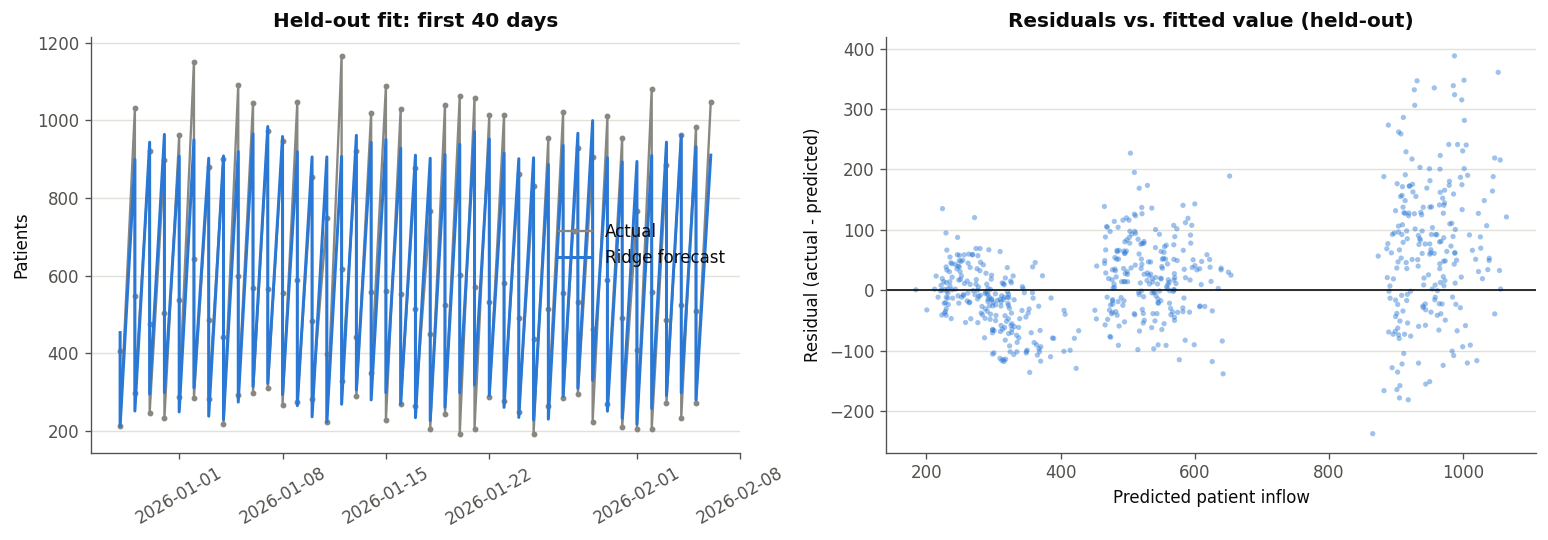

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

window = slice(0, 120)  # first ~40 days of the held-out period
ax = axes[0]
ax.plot(dates_test[window], y_test[window], color=C["muted"], lw=1.4, label="Actual", marker="o", ms=2.5)
ax.plot(dates_test[window], y_pred_test[window], color=C["blue"], lw=1.8, label="Ridge forecast")
ax.set_title("Held-out fit: first 40 days", fontweight="bold", color=C["ink"])
ax.set_ylabel("Patients")
ax.legend(frameon=False)
ax.grid(axis="y", color=C["hair"])
ax.set_axisbelow(True)
for label in ax.get_xticklabels():
    label.set_rotation(30)

ax = axes[1]
resid = y_test - y_pred_test
ax.scatter(y_pred_test, resid, s=10, alpha=0.45, color=C["blue"], edgecolor="none")
ax.axhline(0, color=C["ink"], lw=1)
ax.set_xlabel("Predicted patient inflow")
ax.set_ylabel("Residual (actual - predicted)")
ax.set_title("Residuals vs. fitted value (held-out)", fontweight="bold", color=C["ink"])
ax.grid(axis="y", color=C["hair"])
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**Reading the charts.** The left panel tracks the model against 40 days of
held-out shifts it never trained on — it recovers the sharp Morning /
Evening / Night sawtooth pattern well, since `shift_morning` and
`shift_evening` carry the two largest coefficients by a wide margin. The right
panel checks a modelling assumption: residuals should scatter randomly around
zero with no obvious funnel or curve. They do, with a spread that is roughly
constant across the predicted range — evidence the linear form is a reasonable
fit rather than badly mis-specified.

## 9. What Regularisation Actually Buys Us

The report's argument for Ridge over plain least squares is stability: a large,
unpenalised coefficient vector chases small, accidental patterns in the
training data. This is straightforward to check directly — refit with $\alpha=0$
(plain OLS, still recency-weighted) and compare the coefficient magnitudes and
held-out error against the $\alpha=1.0$ Ridge fit above.

In [10]:
beta_ols = fit_weighted_ridge(X_train, y_train, weights, alpha=0.0)
y_pred_ols_test = X_test @ beta_ols
metrics_ols_test = evaluate(y_test, y_pred_ols_test)

compare_df = pd.DataFrame({
    "OLS (alpha=0)": [np.abs(beta_ols).sum()] + list(evaluate(y_test, y_pred_ols_test).values()),
    "Ridge (alpha=1.0)": [np.abs(beta).sum()] + list(evaluate(y_test, y_pred_test).values()),
}, index=["Sum |coefficients|", "MAE", "RMSE", "R2"])
compare_df

,OLS (alpha=0),Ridge (alpha=1.0)
Sum |coefficients|,"1,242.51","1,114.25"
MAE,65.72,68.01
RMSE,89.47,93.34
R2,0.92,0.92


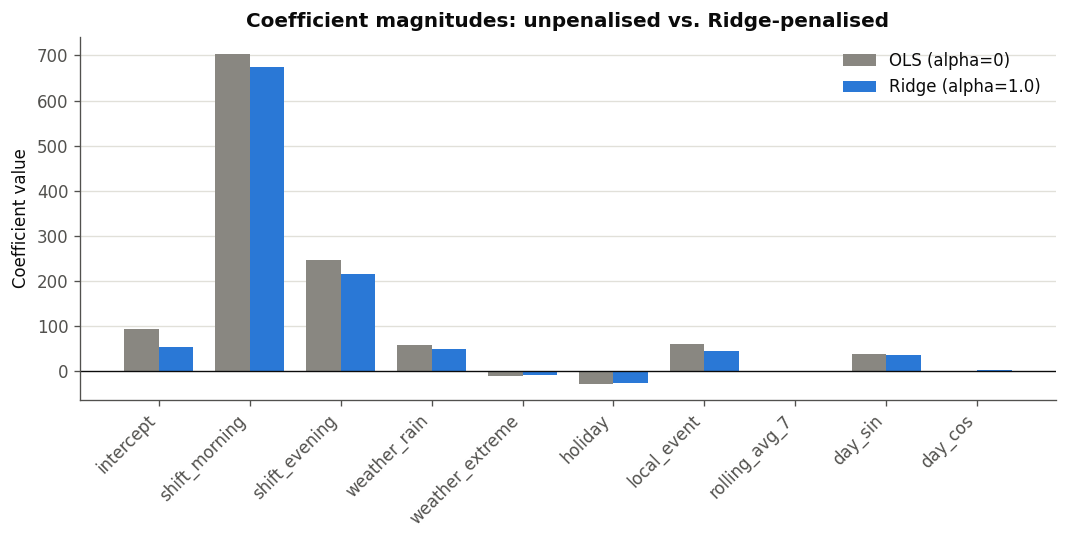

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.6))
idx = np.arange(len(FEATURES) + 1)
width = 0.38
labels = ["intercept"] + FEATURES

ax.bar(idx - width/2, beta_ols, width, label="OLS (alpha=0)", color=C["muted"])
ax.bar(idx + width/2, beta, width, label="Ridge (alpha=1.0)", color=C["blue"])
ax.set_xticks(idx)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.axhline(0, color=C["ink"], lw=0.8)
ax.set_ylabel("Coefficient value")
ax.set_title("Coefficient magnitudes: unpenalised vs. Ridge-penalised", fontweight="bold", color=C["ink"])
ax.legend(frameon=False)
ax.grid(axis="y", color=C["hair"])
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

On this dataset the two fits land close together — the features here are only
mildly collinear, so plain least squares is already fairly stable. The penalty
still visibly shrinks the largest coefficients toward zero without materially
hurting held-out accuracy, which is the entire point of Ridge: a small amount
of bias traded for a meaningful reduction in variance, so the model does not
overreact to noise it happened to see during training.

## 10. Save Predictions for the Ensemble Notebook

Notebook 4 blends this model with the Gradient-Boosted Stumps (Notebook 2) and
Holt-Winters (Notebook 3) forecasts using inverse-MAE weighting. To make that
blend honest, every model's held-out predictions — aligned to the same test
dates — are saved here as a small CSV artifact.

In [12]:
import os
os.makedirs("artifacts", exist_ok=True)

out = pd.DataFrame({
    "date": pd.to_datetime(dates_test),
    "shift_type": df["shift_type"].values[SPLIT:],
    "y_true": y_test,
    "y_pred_ridge": y_pred_test,
})
out.to_csv("artifacts/ridge_predictions.csv", index=False)

print(f"Saved {len(out):,} held-out predictions to artifacts/ridge_predictions.csv")
print(f"Held-out MAE for this model (used as the ensemble weight input in Notebook 4): {metrics_test['MAE']:.3f}")
out.head()

Saved 659 held-out predictions to artifacts/ridge_predictions.csv
Held-out MAE for this model (used as the ensemble weight input in Notebook 4): 68.005


,date,shift_type,y_true,y_pred_ridge
0,2025-12-28,Evening,406.00,453.31
1,2025-12-28,Night,214.00,212.09
2,2025-12-29,Morning,"1,031.00",899.26
3,2025-12-29,Evening,548.00,484.28
4,2025-12-29,Night,299.00,251.33


## Summary

| | |
|---|---|
| **Model** | Recency-weighted Ridge Regression, closed-form |
| **Features** | 9 (Table 1.1) + intercept |
| **Regularisation** | $\alpha = 1.0$ |
| **Recency half-life** | 90 records (~30 days) |
| **Held-out MAE** | see Section 6 above |
| **Held-out R²** | see Section 6 above |

Ridge Regression is the most transparent of MediShift's three models: every
coefficient has a plain, inspectable meaning (Section 7), it refits on a phone
in well under a second, and — as Section 9 shows — the ridge penalty buys
stability without sacrificing held-out accuracy. Its main limitation is exactly
what motivates Notebook 2: a straight line cannot capture an effect that only
shows up in combination, like "rain matters more on a Monday than a Sunday."